In [10]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [11]:
!kaggle datasets list

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [12]:
!kaggle datasets download -d sarcasmos/ai-society

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'


In [15]:
import kagglehub
path = kagglehub.dataset_download('sarcasmos/ai-society')

Using Colab cache for faster access to the 'ai-society' dataset.


In [17]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prashantsharma526/e-commerce-mens-clothing-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/prashantsharma526/e-commerce-mens-clothing-dataset/versions/2


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
train_ds = image_dataset_from_directory(
    path,
    validation_split = 0.2,
    subset = 'training',
    seed = 42,
    image_size = (150 , 150),
    batch_size = 32
)
val_ds = image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(150,150),
    batch_size=32
)
class_names = train_ds.class_names
print('Classes: ', class_names)

Found 8641 files belonging to 2 classes.
Using 6913 files for training.
Found 8641 files belonging to 2 classes.
Using 1728 files for validation.
Classes:  ['dataset_clean', 'sample_images']


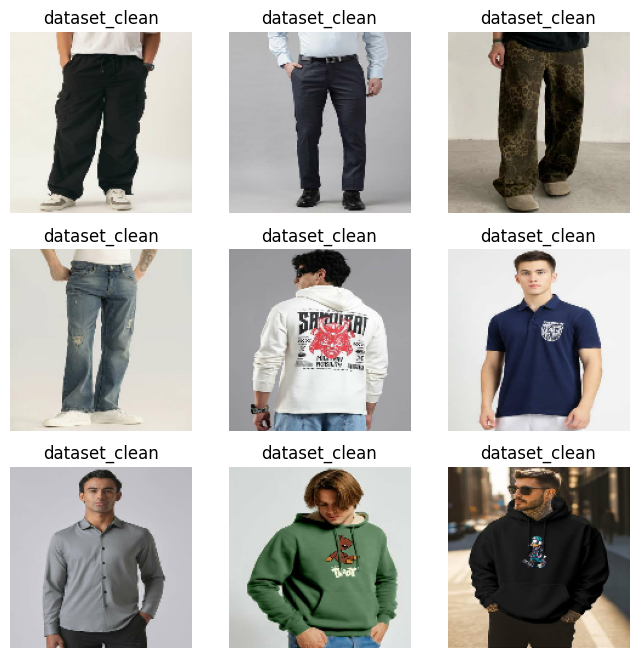

In [ ]:
plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.show()

In [ ]:
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x,y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x,y: (normalization_layer(x), y))

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.9713 - loss: 0.0872 - val_accuracy: 0.9983 - val_loss: 0.0202
Epoch 2/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9977 - loss: 0.0634 - val_accuracy: 0.9983 - val_loss: 0.0295
Epoch 3/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.9975 - loss: 0.0634 - val_accuracy: 0.9983 - val_loss: 0.0193
Epoch 4/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.9972 - loss: 0.0185 - val_accuracy: 0.9983 - val_loss: 0.0157
Epoch 5/5
217/217 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.9971 - loss: 0.0189 - val_accuracy: 0.9983 - val_loss: 0.0170
